# IBM topic sentiment: core analysis

This notebook intentionally excludes the target taxonomy and every
LLM-authored annotation. It uses only gold topic-sentiment labels, model
candidate scores, assigned persona, and randomized prompt factors.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ANALYSIS = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (ANALYSIS / "data").exists():
    ANALYSIS = Path.cwd() / "tasks" / "sentiment" / "analysis"
DATA = ANALYSIS / "data"
FIGURES = ANALYSIS / "figures"

coverage = pd.read_csv(DATA / "coverage_by_model.csv")
summary_model = pd.read_csv(DATA / "summary_by_model.csv")
summary_persona = pd.read_csv(DATA / "summary_by_model_persona.csv")
sensitivity = pd.read_csv(DATA / "factor_sensitivity_macro_f1.csv")
topics = pd.read_csv(DATA / "topic_descriptive_metrics.csv")

## Coverage

The archived run should contain 1,800 configurations × 30 topics = 54,000
successful rows per model. Coverage is a prerequisite for the comparisons
below; it is not a performance metric.

In [2]:
display(coverage)
assert coverage["coverage"].eq(1.0).all()
assert coverage["error_rows"].eq(0).all()
assert coverage["successful_rows"].sum() == 432_000

,model,successful_rows,error_rows,unique_configs,unique_items,expected_rows,coverage,path_exists
0,gemma-3-1b-it,54000,0,1800,30,54000,1.0,True
1,gemma-3-4b-it,54000,0,1800,30,54000,1.0,True
2,gemma-3-12b-it,54000,0,1800,30,54000,1.0,True
3,gemma-3-27b-it,54000,0,1800,30,54000,1.0,True
4,Qwen3-4B,54000,0,1800,30,54000,1.0,True
5,Qwen3-8B,54000,0,1800,30,54000,1.0,True
6,Qwen3-14B,54000,0,1800,30,54000,1.0,True
7,Qwen3-32B,54000,0,1800,30,54000,1.0,True


## Model and assigned-persona performance

Macro-F1 gives equal weight to the negative and positive labels. Each cell in
the heatmap pools 300 prompt configurations for each of the 30 topics (9,000
classifications). The base column has no political persona. The other columns
use the named assigned persona; they do not identify a model's own ideology.

In this run, the base condition has the highest macro-F1 for every model. The
gap is small for some model/persona combinations and much larger for others,
so the defensible conclusion is prompt-condition sensitivity rather than a
uniform family- or size-level law.

,model,n,accuracy,macro_f1,positive_pred_rate
0,gemma-3-1b-it,54000,0.523556,0.512033,0.520333
1,gemma-3-4b-it,54000,0.532815,0.532809,0.370111
2,gemma-3-12b-it,54000,0.562500,0.561306,0.418833
3,gemma-3-27b-it,54000,0.550000,0.549623,0.337741
4,Qwen3-4B,54000,0.579630,0.573188,0.489519
5,Qwen3-8B,54000,0.590370,0.579017,0.530889
6,Qwen3-14B,54000,0.583759,0.581151,0.445574
7,Qwen3-32B,54000,0.585130,0.579665,0.480685


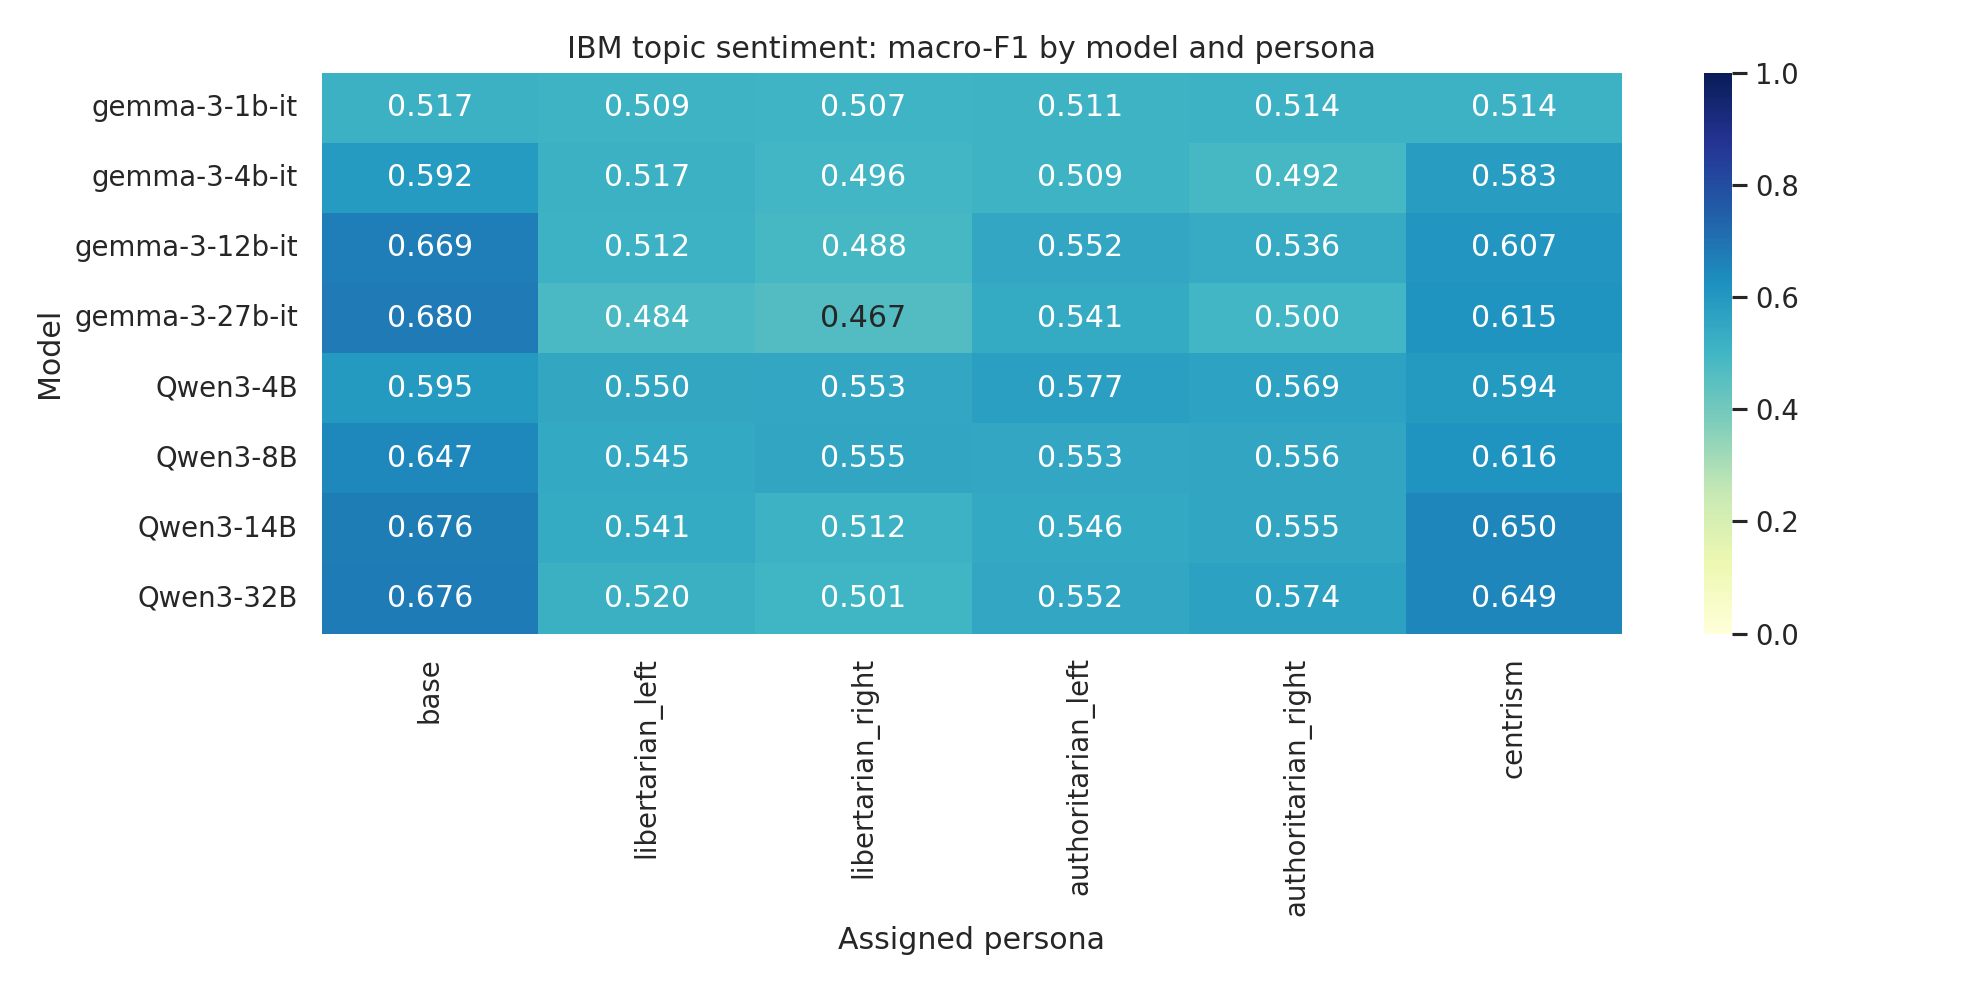

In [3]:
display(summary_model[["model", "n", "accuracy", "macro_f1", "positive_pred_rate"]])
display(Image(filename=str(FIGURES / "ibm_sentiment_macro_f1_model_persona_heatmap.png")))

## Prompt-factor sensitivity

Each named factor cell is a descriptive root-mean-square spread in
configuration-level macro-F1 between the factor's levels, calculated within
persona conditions. `Ideology SD` is the spread of the six persona-condition
means. `Residual RMSE` comes from an additive dummy-coded model. These values
show where measured robustness variation is concentrated; they are not causal
effect estimates and do not sum to total variance.

Instruction wording is the largest named prompt-factor component for six of
eight models. The ordering of the other components varies by checkpoint.

,model,metric,Ideology SD,Total Var SD,Residual RMSE,Context,Instruction,Key Type,Permutation,Persona
0,gemma-3-1b-it,macro_f1,0.003103,0.121515,0.106120,0.019329,0.029714,0.033316,0.033915,0.027045
1,gemma-3-4b-it,macro_f1,0.051955,0.160275,0.139781,0.025593,0.058996,0.018422,0.026643,0.038361
2,gemma-3-12b-it,macro_f1,0.070820,0.150961,0.127611,0.043326,0.045225,0.027430,0.025318,0.032129
3,gemma-3-27b-it,macro_f1,0.084835,0.146840,0.113663,0.033887,0.059023,0.012775,0.028754,0.032039
4,Qwen3-4B,macro_f1,0.022495,0.173636,0.147456,0.027636,0.065768,0.046468,0.037556,0.032196
5,Qwen3-8B,macro_f1,0.045899,0.173645,0.135569,0.056270,0.086644,0.025346,0.024647,0.031988
6,Qwen3-14B,macro_f1,0.068059,0.164450,0.129691,0.045065,0.080033,0.038429,0.023204,0.026133
7,Qwen3-32B,macro_f1,0.070438,0.173385,0.121758,0.070955,0.089666,0.044203,0.015372,0.034425


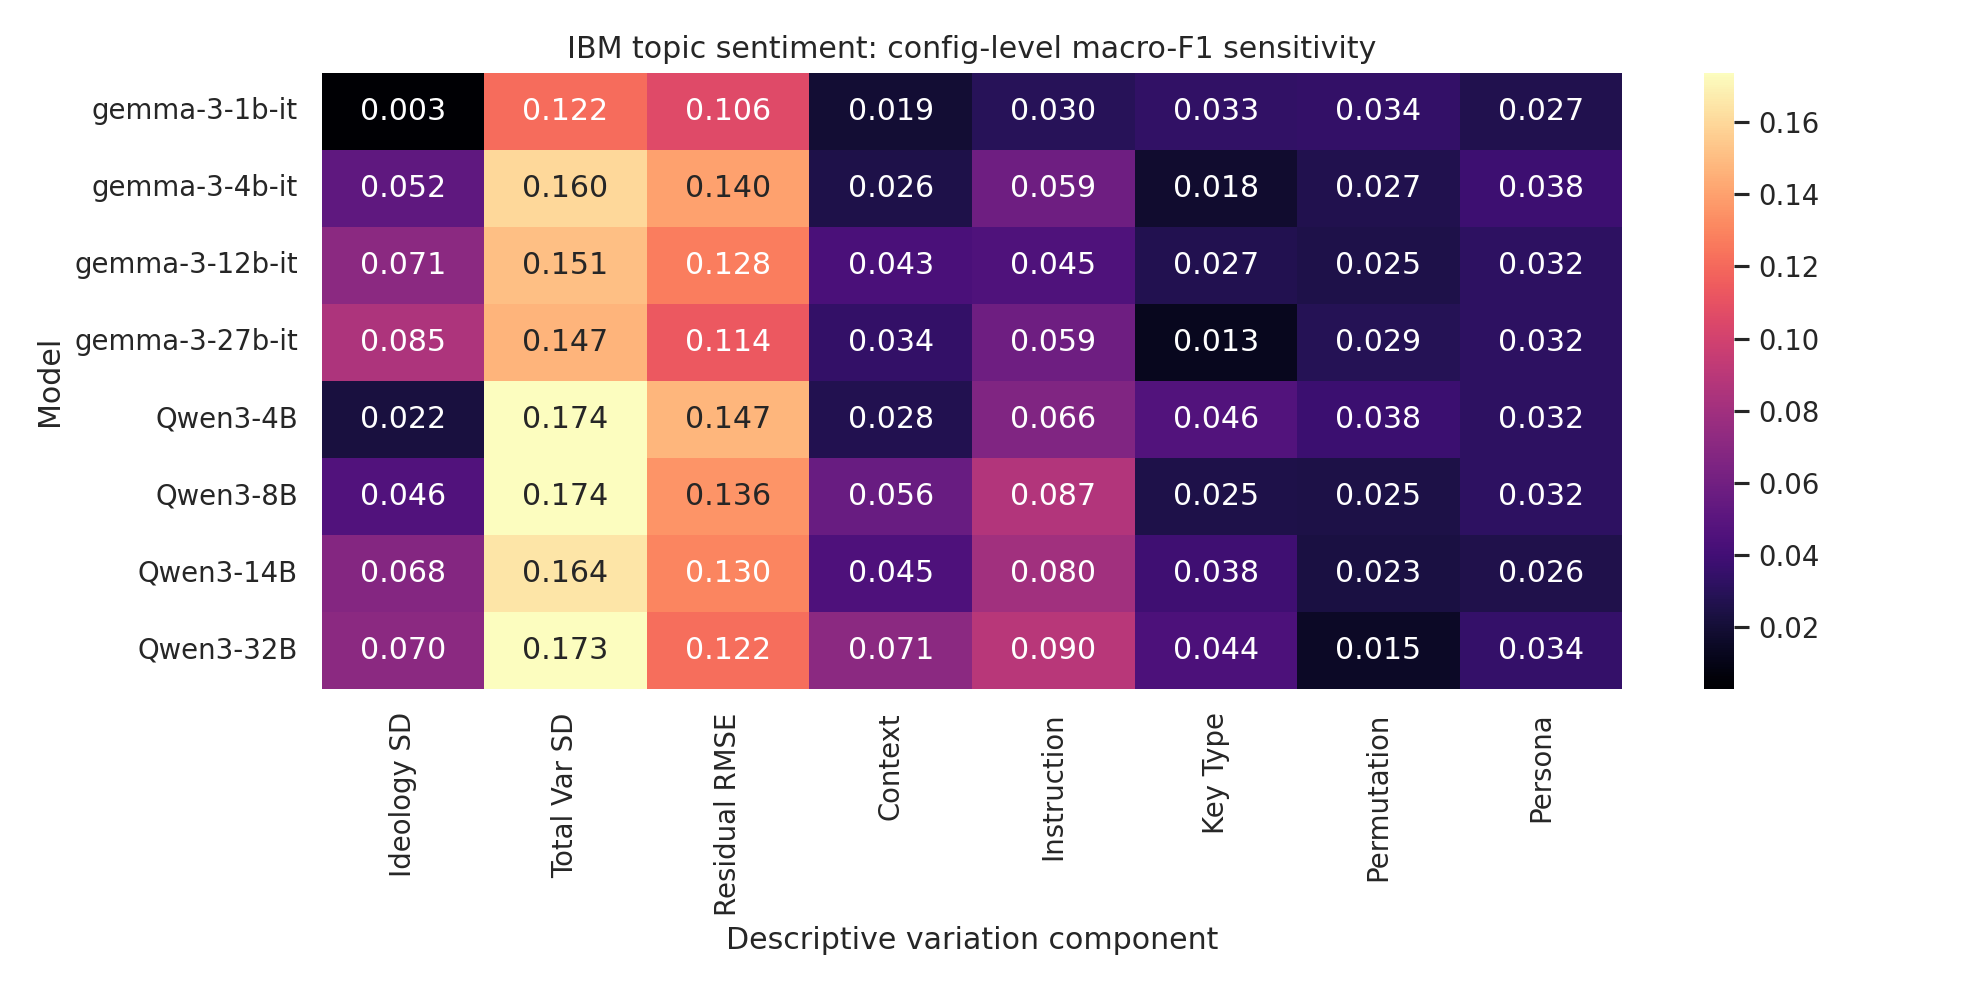

In [4]:
display(sensitivity)
display(Image(filename=str(FIGURES / "ibm_sentiment_factor_sensitivity_macro_f1.png")))

## Topic-level descriptive table

There is one gold label per topic, so per-topic macro-F1 would be misleading.
The released table instead reports accuracy, positive-prediction rate, and
mean candidate confidence for each model × persona × topic over 300 prompt
configurations. It supports item-level inspection without an added taxonomy.

In [5]:
display(topics.head(12))
assert len(topics) == 8 * 6 * 30
assert topics.groupby(["model", "ideology"])["item_index"].nunique().eq(30).all()

,model,ideology,item_index,source_item_id,topic,target,gold_label,n,accuracy,positive_pred_rate,mean_confidence
0,gemma-3-1b-it,base,0,1,This house believes that the sale of violent v...,the sale of violent video games to minors,NEGATIVE,300,0.543333,0.456667,0.890881
1,gemma-3-1b-it,base,1,21,This house supports the one-child policy of th...,the one-child policy of the republic of China,POSITIVE,300,0.496667,0.496667,0.898127
2,gemma-3-1b-it,base,2,61,This house would permit the use of performance...,the use of performance enhancing drugs in prof...,POSITIVE,300,0.516667,0.516667,0.917216
3,gemma-3-1b-it,base,3,81,This house would make physical education compu...,make physical education compulsory,POSITIVE,300,0.526667,0.526667,0.895478
4,gemma-3-1b-it,base,4,101,This house believes in the use of affirmative ...,the use of affirmative action,POSITIVE,300,0.593333,0.593333,0.921357
5,gemma-3-1b-it,base,5,121,This house would ban boxing,boxing,NEGATIVE,300,0.510000,0.490000,0.918008
6,gemma-3-1b-it,base,6,181,This house would embrace multiculturalism,multiculturalism,POSITIVE,300,0.613333,0.613333,0.910356
7,gemma-3-1b-it,base,7,221,This house would ban gambling,gambling,NEGATIVE,300,0.500000,0.500000,0.915087
8,gemma-3-1b-it,base,8,323,This house believes that the right to asylum s...,the right to asylum,NEGATIVE,300,0.516667,0.483333,0.898739
9,gemma-3-1b-it,base,9,381,This house would abolish the monarchy,the monarchy,NEGATIVE,300,0.476667,0.523333,0.904767
